# Heart Failure Prediction

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              roc_auc_score, classification_report,
                              ConfusionMatrixDisplay, RocCurveDisplay)
from scipy.sparse import issparse
import joblib
import warnings
warnings.filterwarnings('ignore')

In [40]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

# print("Path to dataset files:", path)

# Data Exploration

In [41]:
df = pd.read_csv('D:heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [43]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


**Observations:**
- `RestingBP` has min = 0 → needs fixing
- `Cholesterol` has min = 0 → needs fixing
- `Oldpeak` has min = -2.6 → needs fixing

In [44]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

No null values found.

In [45]:
df.duplicated().sum()

np.int64(0)

No duplicates found.

In [46]:
df['FastingBS'].unique()

array([0, 1])

## Distributions Before Cleaning

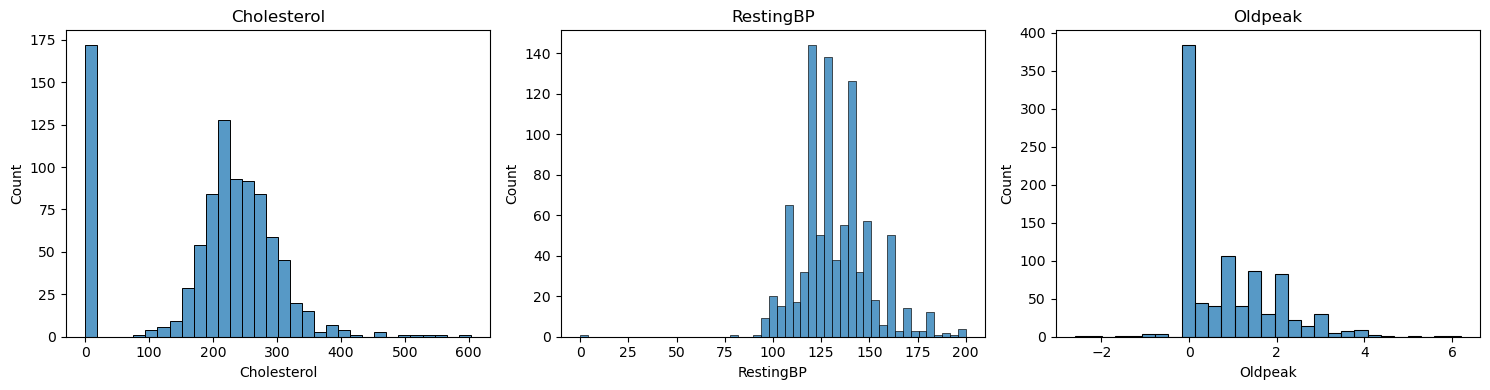

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['Cholesterol'], ax=axes[0])
axes[0].set_title('Cholesterol')
sns.histplot(df['RestingBP'], ax=axes[1])
axes[1].set_title('RestingBP')
sns.histplot(df['Oldpeak'], ax=axes[2])
axes[2].set_title('Oldpeak')
plt.tight_layout()
plt.show()

# Data Cleaning

## Cholesterol
Replace zero values with the minimum non-zero value per class.

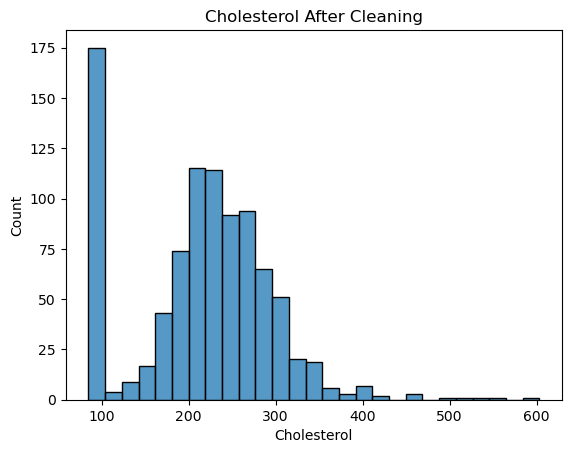

In [48]:
for cls in df['HeartDisease'].unique():
    min_chol = df[(df['Cholesterol'] > 0) & (df['HeartDisease'] == cls)]['Cholesterol'].min()
    df.loc[(df['Cholesterol'] == 0) & (df['HeartDisease'] == cls), 'Cholesterol'] = min_chol

sns.histplot(data=df, x='Cholesterol')
plt.title('Cholesterol After Cleaning')
plt.show()

## RestingBP
Replace zero values with the minimum non-zero value per class.

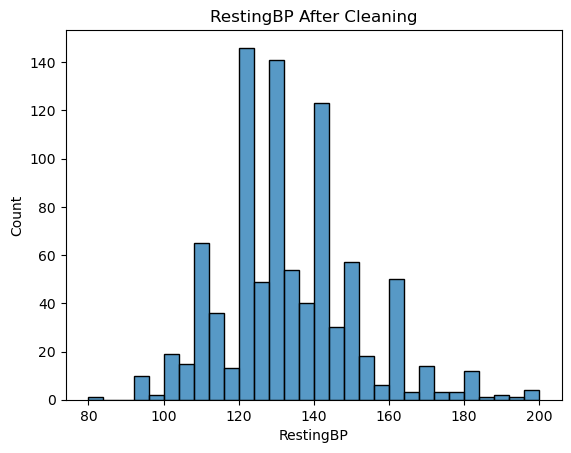

In [49]:
for cls in df['HeartDisease'].unique():
    min_bp = df[(df['RestingBP'] > 0) & (df['HeartDisease'] == cls)]['RestingBP'].min()
    df.loc[(df['RestingBP'] == 0) & (df['HeartDisease'] == cls), 'RestingBP'] = min_bp

sns.histplot(df['RestingBP'])
plt.title('RestingBP After Cleaning')
plt.show()

## Oldpeak
Replace extreme negative values with the minimum valid value per class.

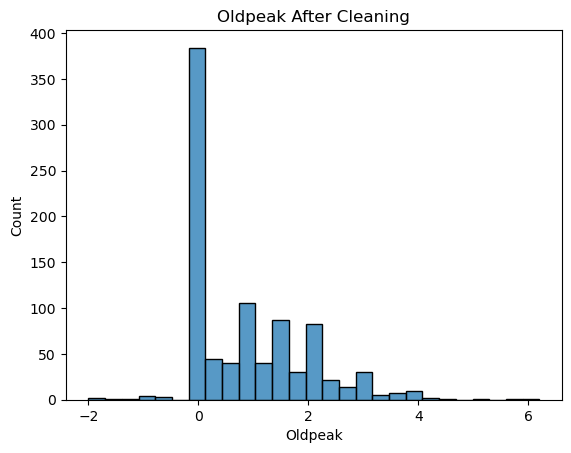

In [50]:
for cls in df['HeartDisease'].unique():
    min_oldpeak = df[(df['Oldpeak'] >= -2) & (df['HeartDisease'] == cls)]['Oldpeak'].min()
    df.loc[(df['Oldpeak'] < -2) & (df['HeartDisease'] == cls), 'Oldpeak'] = min_oldpeak

sns.histplot(df['Oldpeak'])
plt.title('Oldpeak After Cleaning')
plt.show()

# Feature Engineering

In [51]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 40, 50, 60, 100],
    labels=['Young', 'Middle', 'Senior', 'Elder']
).astype('object')

df['ST_Level'] = pd.cut(
    df['Oldpeak'],
    bins=[-3, 0, 2, 6],
    labels=['Low', 'Normal', 'High']
).astype('object')

df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,AgeGroup,ST_Level
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0,Young,Low
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1,Middle,Normal
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0,Young,Low
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1,Middle,Normal
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0,Senior,Low


# Visualization

## Age Distribution of Heart Disease Patients

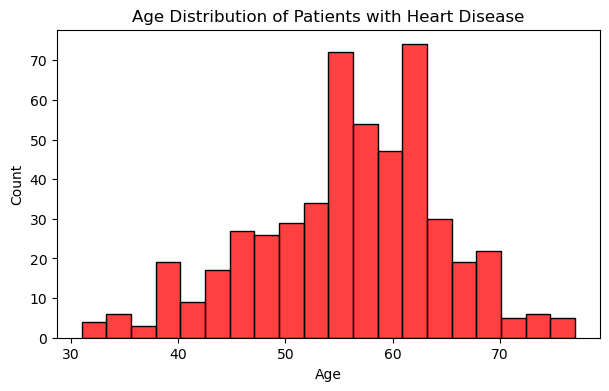

In [52]:
heart_patients = df[df['HeartDisease'] == 1]
plt.figure(figsize=(7, 4))
sns.histplot(heart_patients['Age'], bins=20, color='red')
plt.title('Age Distribution of Patients with Heart Disease')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

## Target Distribution

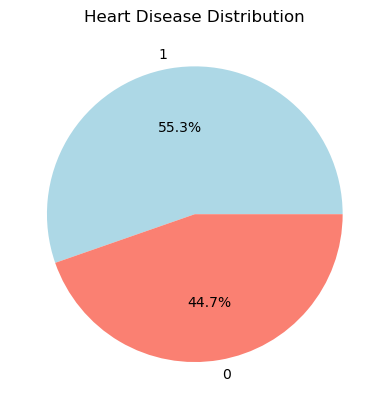

In [53]:
df['HeartDisease'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', colors=['lightblue', 'salmon']
)
plt.title('Heart Disease Distribution')
plt.ylabel('')
plt.show()

## Target, Age & Sex Overview

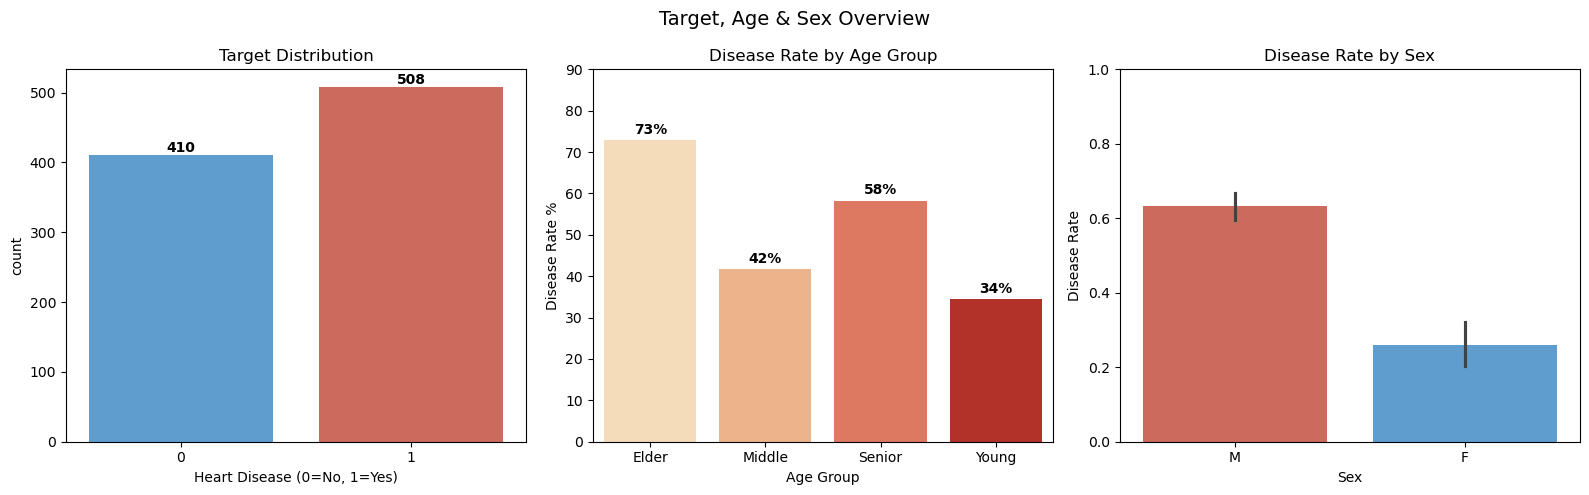

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Target, Age & Sex Overview', fontsize=14)

sns.countplot(x='HeartDisease', data=df, palette=['#4B9FE0', '#E05C4B'], ax=axes[0])
axes[0].set_title('Target Distribution')
axes[0].set_xlabel('Heart Disease (0=No, 1=Yes)')
for p in axes[0].patches:
    axes[0].text(p.get_x() + p.get_width()/2, p.get_height() + 5,
                 str(int(p.get_height())), ha='center', fontweight='bold')

age_rate = df.groupby('AgeGroup', observed=True)['HeartDisease'].mean() * 100
sns.barplot(x=age_rate.index, y=age_rate.values, ax=axes[1], palette='OrRd')
axes[1].set_title('Disease Rate by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Disease Rate %')
axes[1].set_ylim(0, 90)
for i, v in enumerate(age_rate.values):
    axes[1].text(i, v + 1.5, f'{v:.0f}%', ha='center', fontweight='bold')

sns.barplot(x='Sex', y='HeartDisease', data=df, palette=['#E05C4B', '#4B9FE0'], ax=axes[2])
axes[2].set_title('Disease Rate by Sex')
axes[2].set_ylabel('Disease Rate')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## ChestPainType & ST_Slope Analysis

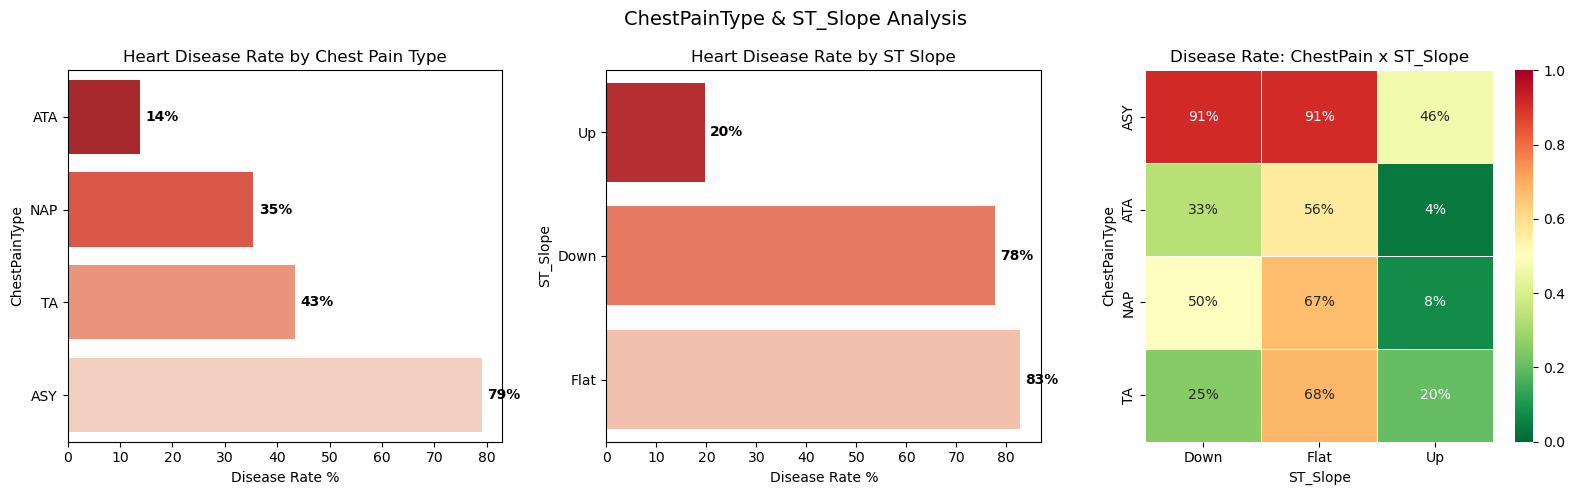

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('ChestPainType & ST_Slope Analysis', fontsize=14)

cpt_rate = df.groupby('ChestPainType')['HeartDisease'].mean().sort_values()
sns.barplot(x=cpt_rate.values * 100, y=cpt_rate.index, ax=axes[0], palette='Reds_r', orient='h')
axes[0].set_title('Heart Disease Rate by Chest Pain Type')
axes[0].set_xlabel('Disease Rate %')
for i, v in enumerate(cpt_rate.values):
    axes[0].text(v * 100 + 1, i, f'{v:.0%}', va='center', fontweight='bold')

slope_rate = df.groupby('ST_Slope')['HeartDisease'].mean().sort_values()
sns.barplot(x=slope_rate.values * 100, y=slope_rate.index, ax=axes[1], palette='Reds_r', orient='h')
axes[1].set_title('Heart Disease Rate by ST Slope')
axes[1].set_xlabel('Disease Rate %')
for i, v in enumerate(slope_rate.values):
    axes[1].text(v * 100 + 1, i, f'{v:.0%}', va='center', fontweight='bold')

pivot = df.pivot_table(values='HeartDisease', index='ChestPainType', columns='ST_Slope', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.0%', cmap='RdYlGn_r', linewidths=0.5, ax=axes[2], vmin=0, vmax=1)
axes[2].set_title('Disease Rate: ChestPain x ST_Slope')

plt.tight_layout()
plt.show()

## Cholesterol & RestingBP Analysis

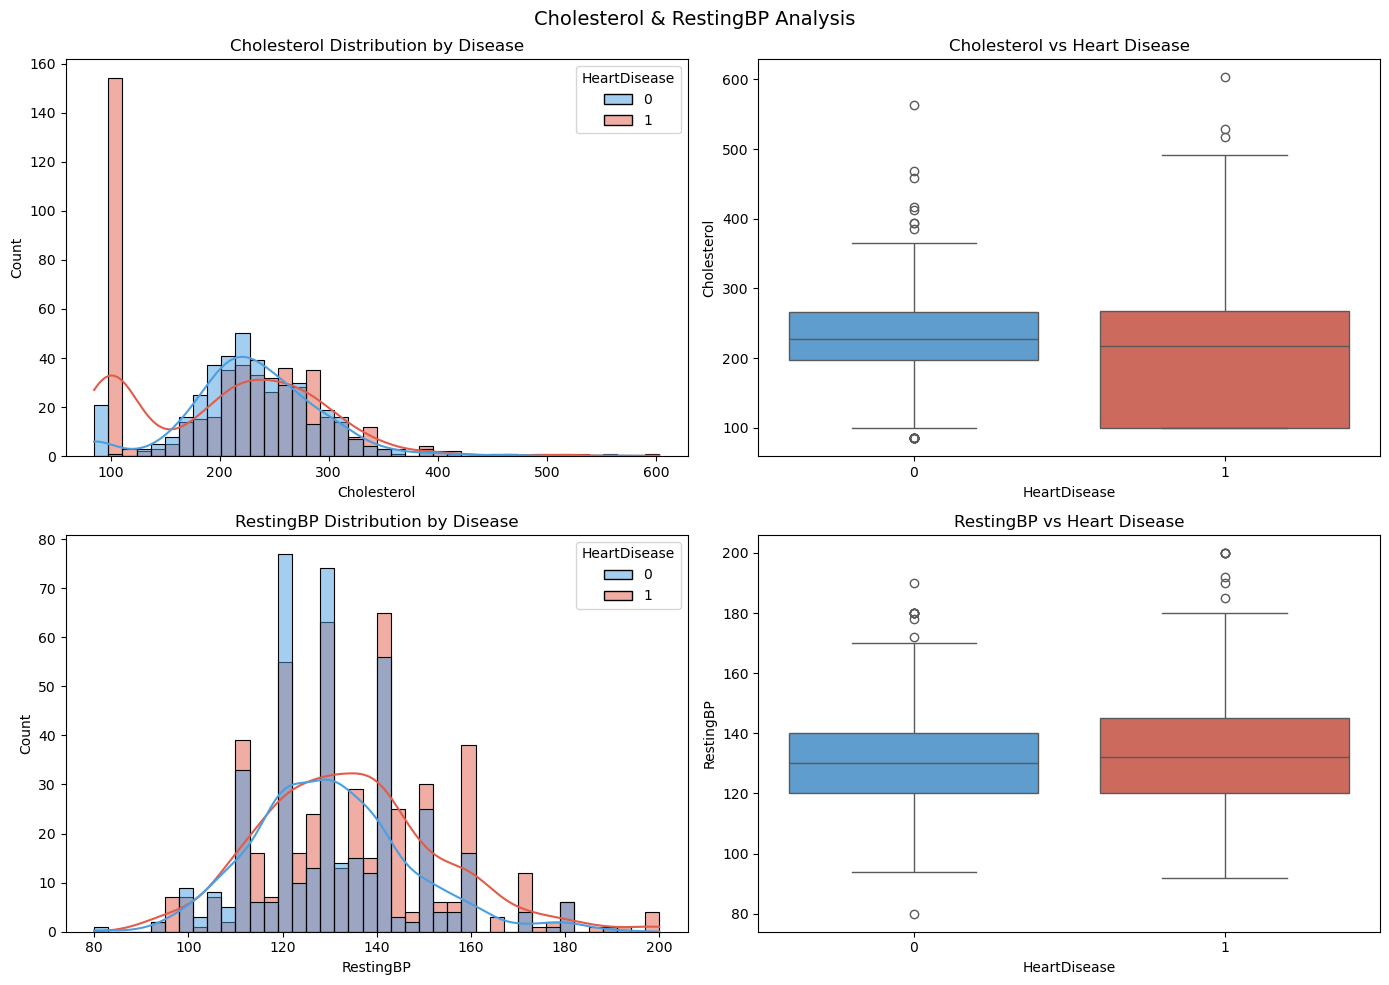

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Cholesterol & RestingBP Analysis', fontsize=14)

sns.histplot(data=df, x='Cholesterol', hue='HeartDisease', kde=True, bins=40,
             palette=['#4B9FE0', '#E05C4B'], ax=axes[0, 0])
axes[0, 0].set_title('Cholesterol Distribution by Disease')

sns.boxplot(x='HeartDisease', y='Cholesterol', data=df,
            palette=['#4B9FE0', '#E05C4B'], ax=axes[0, 1])
axes[0, 1].set_title('Cholesterol vs Heart Disease')

sns.histplot(data=df, x='RestingBP', hue='HeartDisease', kde=True, bins=40,
             palette=['#4B9FE0', '#E05C4B'], ax=axes[1, 0])
axes[1, 0].set_title('RestingBP Distribution by Disease')

sns.boxplot(x='HeartDisease', y='RestingBP', data=df,
            palette=['#4B9FE0', '#E05C4B'], ax=axes[1, 1])
axes[1, 1].set_title('RestingBP vs Heart Disease')

plt.tight_layout()
plt.show()

## Pairplot

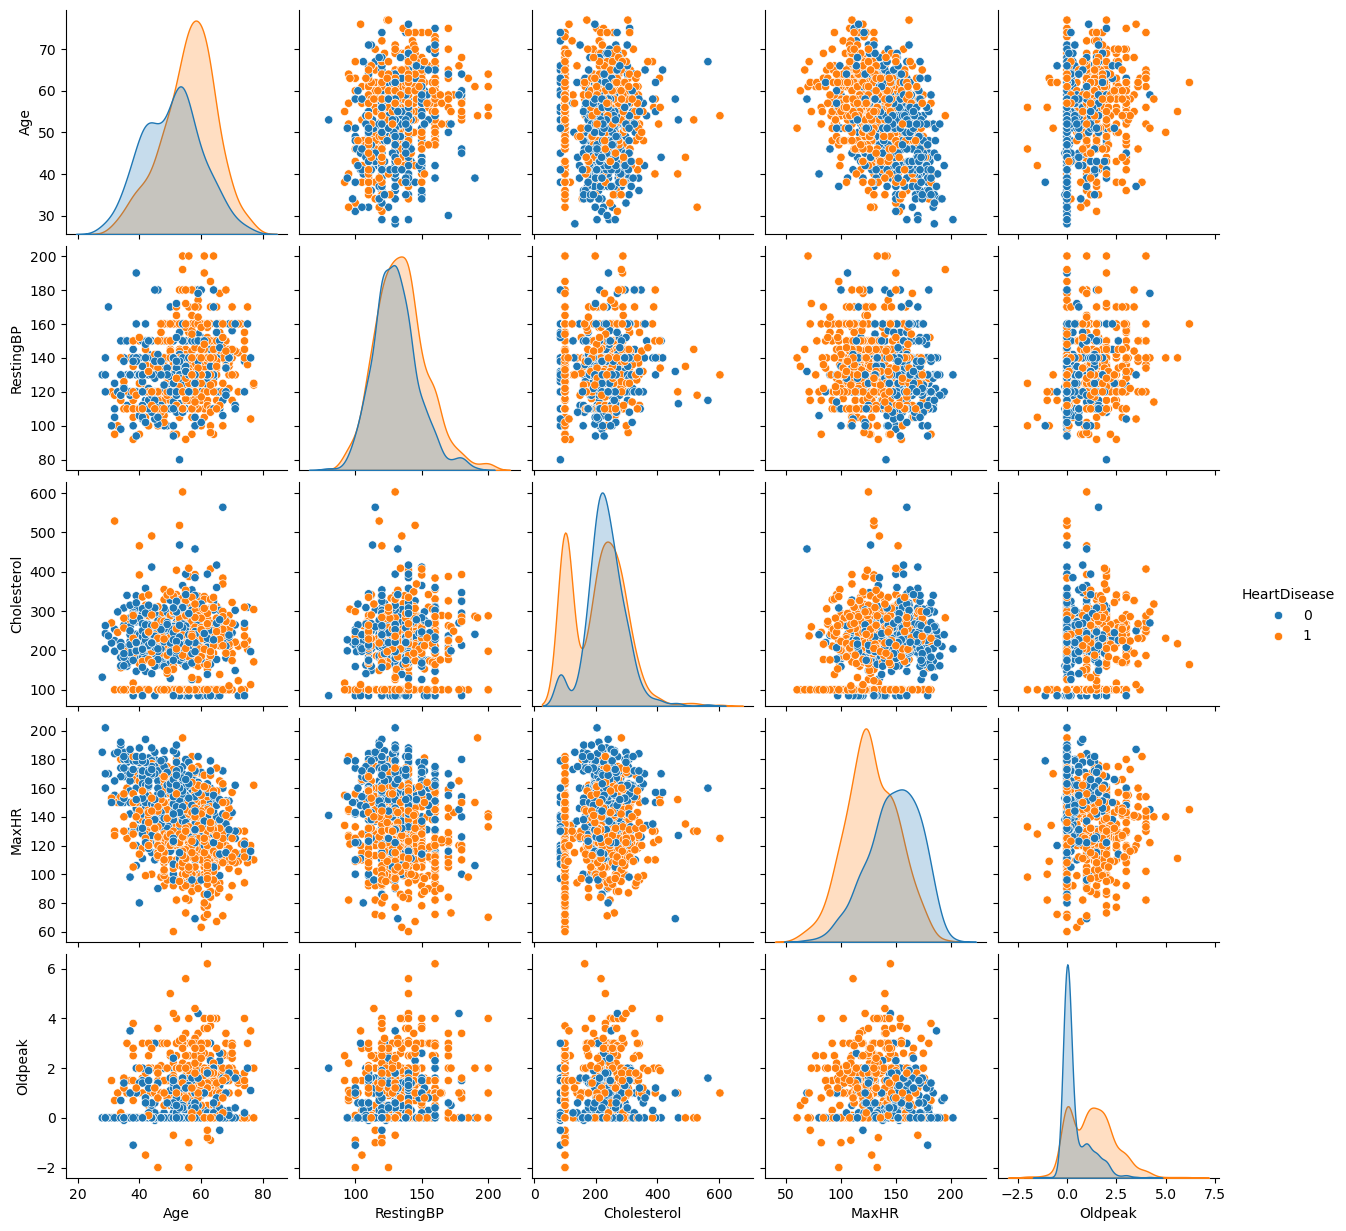

In [57]:
sns.pairplot(df, hue='HeartDisease', vars=['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak'])
plt.show()

## Correlation Heatmap

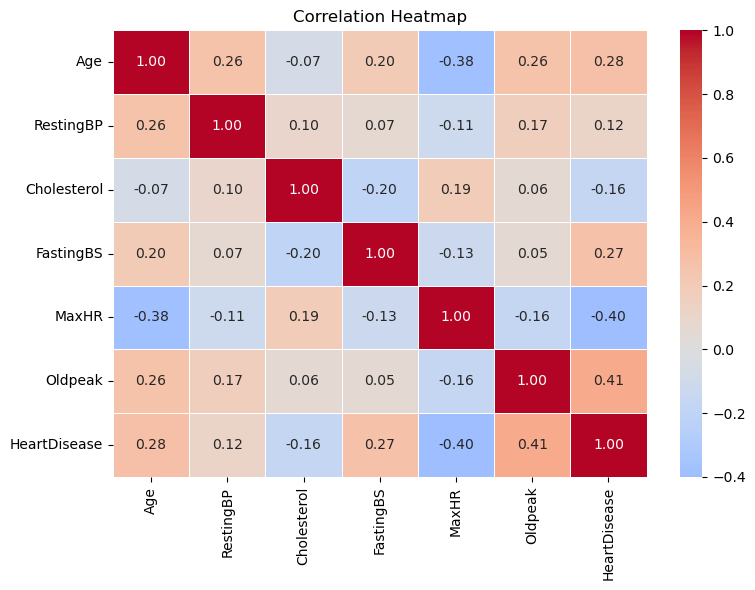

In [58]:
plt.figure(figsize=(8, 6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# Modeling

## Encoding

In [59]:
le = LabelEncoder()
oe = OrdinalEncoder()

df['Sex']            = le.fit_transform(df['Sex'])
df['ExerciseAngina'] = le.fit_transform(df['ExerciseAngina'])

df['ST_Slope'] = oe.fit_transform(df[['ST_Slope']])
df['AgeGroup'] = oe.fit_transform(df[['AgeGroup']])
df['ST_Level'] = oe.fit_transform(df[['ST_Level']])

ohe = OneHotEncoder(drop='first', sparse_output=False)
ohe_cols    = ['ChestPainType', 'RestingECG']
ohe_encoded = ohe.fit_transform(df[ohe_cols])
ohe_names   = ohe.get_feature_names_out(ohe_cols)
df = df.drop(columns=ohe_cols)
df = pd.concat([df, pd.DataFrame(ohe_encoded, columns=ohe_names, index=df.index)], axis=1)

bool_cols = df.select_dtypes(include='bool').columns.tolist()
df[bool_cols] = df[bool_cols].astype(int)

print('Shape:', df.shape)
print('Non-numeric:', df.select_dtypes(include='object').columns.tolist())
df.head()

Shape: (918, 17)
Non-numeric: []


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,AgeGroup,ST_Level,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST
0,40,1,140,289,0,172,0,0.0,2.0,0,3.0,1.0,1.0,0.0,0.0,1.0,0.0
1,49,0,160,180,0,156,0,1.0,1.0,1,1.0,2.0,0.0,1.0,0.0,1.0,0.0
2,37,1,130,283,0,98,0,0.0,2.0,0,3.0,1.0,1.0,0.0,0.0,0.0,1.0
3,48,0,138,214,0,108,1,1.5,1.0,1,1.0,2.0,0.0,0.0,0.0,1.0,0.0
4,54,1,150,195,0,122,0,0.0,2.0,0,2.0,1.0,0.0,1.0,0.0,1.0,0.0


## Train / Test Split

In [60]:
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train:', X_train.shape)
print('Test :', X_test.shape)

Train: (734, 16)
Test : (184, 16)


## Scaling

In [61]:
scaler = StandardScaler()
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

X_train['ST_Level'] = X_train['ST_Level'].fillna(X_train['ST_Level'].median())
X_test['ST_Level']  = X_test['ST_Level'].fillna(X_train['ST_Level'].median())

X_train.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,AgeGroup,ST_Level,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST
485,0.970012,1,0.339016,-0.045253,1,-0.324520,1,0.317008,1.0,0.0,2.0,1.0,0.0,0.0,0.0,1.0
486,0.122028,1,-1.266031,-0.083638,1,1.689837,0,-0.442156,2.0,2.0,2.0,1.0,0.0,0.0,0.0,1.0
117,0.546020,0,-0.159102,1.502941,1,-0.247045,1,0.601694,1.0,2.0,2.0,0.0,0.0,0.0,0.0,1.0
361,-0.725956,1,1.501291,-1.542267,0,-0.479470,1,-0.821738,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
296,-0.407962,1,0.671094,-1.542267,1,0.101594,1,-0.157470,1.0,1.0,2.0,0.0,0.0,0.0,1.0,0.0


## Model Comparison

In [62]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(random_state=42),
    'AdaBoost'            : AdaBoostClassifier(random_state=42),
    'SVM'                 : SVC(probability=True, random_state=42),
    'KNN'                 : KNeighborsClassifier(),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Naive Bayes'         : GaussianNB(),
}

results = []
for name, model in models.items():
    pipeline = Pipeline([('model', model)])
    pipeline.fit(X_train, y_train)
    y_pred  = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    results.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'F1'       : f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).set_index('Model').round(4)
print(results_df)

                     Accuracy      F1  Precision  Recall  ROC-AUC
Model                                                            
Gradient Boosting      0.9293  0.9347     0.9588  0.9118   0.9613
Random Forest          0.9130  0.9223     0.9135  0.9314   0.9503
AdaBoost               0.9022  0.9118     0.9118  0.9118   0.9553
Naive Bayes            0.8859  0.8995     0.8785  0.9216   0.9285
SVM                    0.8804  0.8942     0.8774  0.9118   0.9193
Logistic Regression    0.8696  0.8835     0.8750  0.8922   0.9054
KNN                    0.8587  0.8750     0.8585  0.8922   0.9216
Decision Tree          0.8207  0.8451     0.8108  0.8824   0.8131


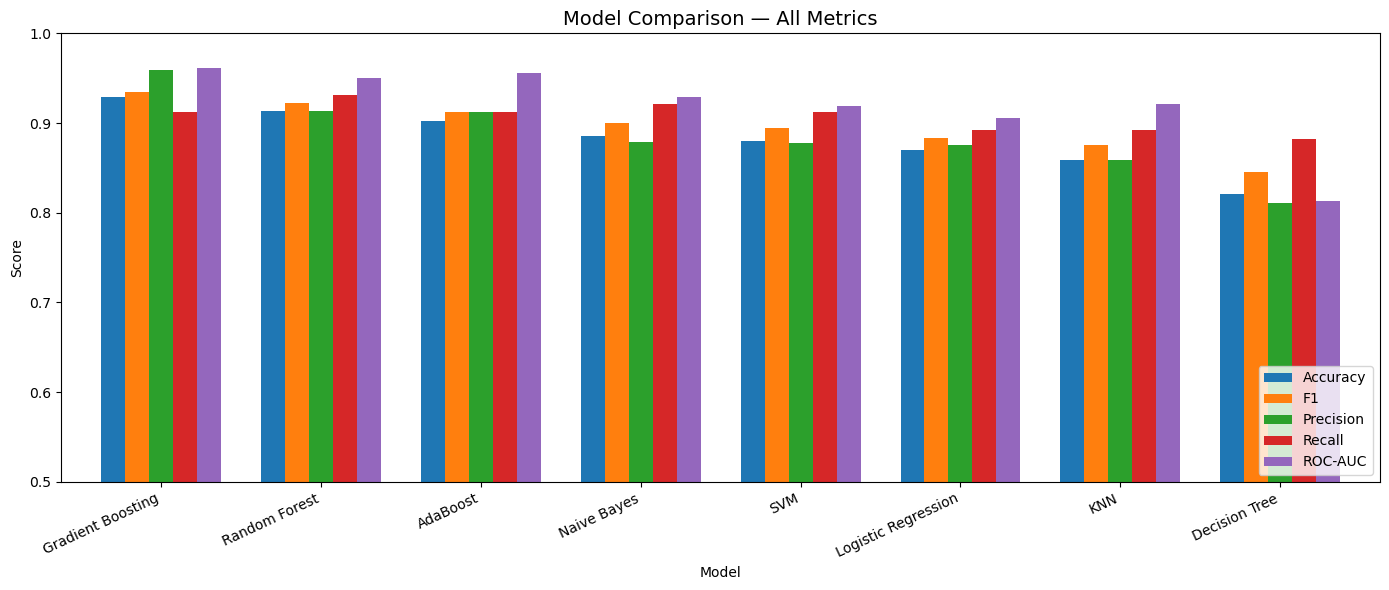

In [63]:
results_df[['Accuracy', 'F1', 'Precision', 'Recall', 'ROC-AUC']].plot(
    kind='bar', figsize=(14, 6), width=0.75
)
plt.title('Model Comparison — All Metrics', fontsize=14)
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=25, ha='right')
plt.ylim(0.5, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Hyperparameter Tuning

In [64]:
param_dist = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [3, 4, 5, 6],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.2],
    'min_samples_split': [2, 5, 10],
    'subsample'        : [0.7, 0.8, 0.9, 1.0],
    'max_features'     : ['sqrt', 'log2', None],
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=50, cv=skf, scoring='accuracy',
    random_state=42, n_jobs=-1, verbose=1
)

search.fit(X_train, y_train)

print('Best Params  :', search.best_params_)
print('Best CV Score:', f'{search.best_score_:.4f}')
print('Test Accuracy:', f'{accuracy_score(y_test, search.best_estimator_.predict(X_test)):.4f}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Params  : {'subsample': 1.0, 'n_estimators': 200, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': 3, 'learning_rate': 0.1}
Best CV Score: 0.8883
Test Accuracy: 0.9402


## Final Evaluation

              precision    recall  f1-score   support

  No Disease       0.92      0.95      0.93        82
     Disease       0.96      0.93      0.95       102

    accuracy                           0.94       184
   macro avg       0.94      0.94      0.94       184
weighted avg       0.94      0.94      0.94       184



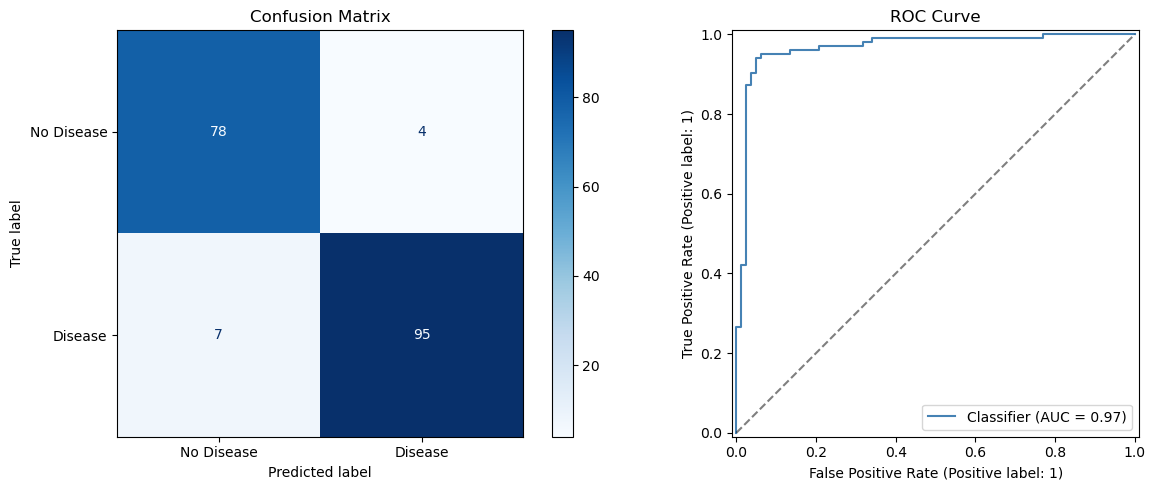

In [65]:
y_pred_final  = search.best_estimator_.predict(X_test)
y_proba_final = search.best_estimator_.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_final, target_names=['No Disease', 'Disease']))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final,
    display_labels=['No Disease', 'Disease'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix')

RocCurveDisplay.from_predictions(y_test, y_proba_final, ax=axes[1], color='steelblue')
axes[1].set_title('ROC Curve')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)

plt.tight_layout()
plt.show()

## Threshold Tuning

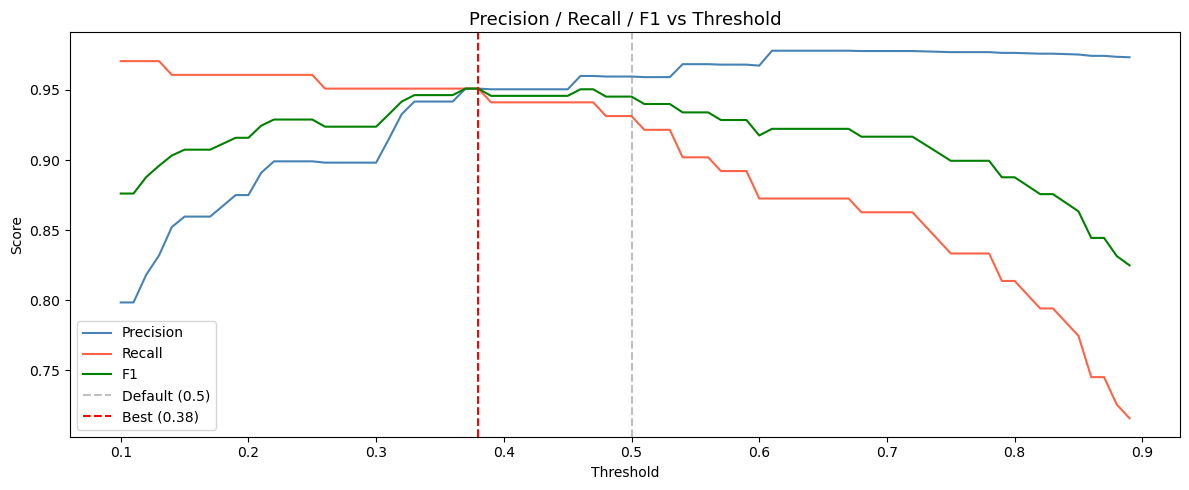

Best Threshold : 0.38
Precision      : 0.9510
Recall         : 0.9510
F1             : 0.9510


In [66]:
thresholds = np.arange(0.1, 0.9, 0.01)
results_thresh = []

for thresh in thresholds:
    y_pred_thresh = (y_proba_final >= thresh).astype(int)
    results_thresh.append({
        'Threshold': thresh,
        'Precision': precision_score(y_test, y_pred_thresh, zero_division=0),
        'Recall'   : recall_score(y_test, y_pred_thresh, zero_division=0),
        'F1'       : f1_score(y_test, y_pred_thresh, zero_division=0),
    })

thresh_df = pd.DataFrame(results_thresh)
best = thresh_df[thresh_df['Recall'] >= 0.95].sort_values('F1', ascending=False).iloc[0]

plt.figure(figsize=(12, 5))
plt.plot(thresh_df['Threshold'], thresh_df['Precision'], label='Precision', color='steelblue')
plt.plot(thresh_df['Threshold'], thresh_df['Recall'],    label='Recall',    color='tomato')
plt.plot(thresh_df['Threshold'], thresh_df['F1'],        label='F1',        color='green')
plt.axvline(0.5, color='gray',  linestyle='--', alpha=0.5, label='Default (0.5)')
plt.axvline(best['Threshold'], color='red', linestyle='--', label=f"Best ({best['Threshold']:.2f})")
plt.title('Precision / Recall / F1 vs Threshold', fontsize=13)
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Best Threshold : {best["Threshold"]:.2f}')
print(f'Precision      : {best["Precision"]:.4f}')
print(f'Recall         : {best["Recall"]:.4f}')
print(f'F1             : {best["F1"]:.4f}')

In [67]:
best_threshold = 0.40
y_pred_best    = (y_proba_final >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_best, target_names=['No Disease', 'Disease']))

compare = pd.DataFrame({
    'Default (0.50)': [0.9457, 0.9500, 0.9694, 0.9314],
    'Tuned   (0.40)': [
        accuracy_score(y_test, y_pred_best),
        f1_score(y_test, y_pred_best),
        precision_score(y_test, y_pred_best),
        recall_score(y_test, y_pred_best),
    ]
}, index=['Accuracy', 'F1', 'Precision', 'Recall'])
print(compare.round(4))

              precision    recall  f1-score   support

  No Disease       0.93      0.94      0.93        82
     Disease       0.95      0.94      0.95       102

    accuracy                           0.94       184
   macro avg       0.94      0.94      0.94       184
weighted avg       0.94      0.94      0.94       184

           Default (0.50)  Tuned   (0.40)
Accuracy           0.9457          0.9402
F1                 0.9500          0.9458
Precision          0.9694          0.9505
Recall             0.9314          0.9412


## Save Model & Predict Function

In [68]:
joblib.dump(search.best_estimator_, 'heart_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print('Model saved successfully!')

Model saved successfully!


In [69]:
def predict_patient(data: dict, threshold: float = 0.40):
    input_df = pd.DataFrame([data])
    input_df = input_df[X_train.columns]
    input_df[num_cols] = scaler.transform(input_df[num_cols])
    probability = search.best_estimator_.predict_proba(input_df)[0][1]
    prediction  = int(probability >= threshold)
    print('=' * 40)
    print(f"Prediction  : {'Disease' if prediction == 1 else 'No Disease'}")
    print(f'Probability : {probability:.2%}')
    print(f'Threshold   : {threshold}')
    print('=' * 40)
    return prediction, probability


sample_patient = {
    'Age': 55, 'Sex': 1, 'RestingBP': 140,
    'Cholesterol': 230, 'FastingBS': 1, 'MaxHR': 120,
    'ExerciseAngina': 1, 'Oldpeak': 2.0, 'ST_Slope': 1,
    'AgeGroup': 1, 'ST_Level': 1,
    'ChestPainType_ATA': 0, 'ChestPainType_NAP': 0, 'ChestPainType_TA': 0,
    'RestingECG_Normal': 1, 'RestingECG_ST': 0,
}

predict_patient(sample_patient)

Prediction  : Disease
Probability : 97.97%
Threshold   : 0.4


(1, np.float64(0.9797395867757606))